# Validation: fidelity of the output to the HCS

This notebook checks how closely the scenario with no event (`normal`) and the *general* population (freelance drivers, general passengers) reproduces the source traffic and ride-hailing data of San Francisco it is built from.

**Source data.**
- *Ride-hailing*: SFCTA TNC trip statistics (`validation/datasets/source/sf_trip_stats_taz.csv`), average pickups and dropoffs per TAZ, day of week and hour.
- *Traffic*: SFMTA traffic counts distributed per ZIP and hour by the simulator to generate the traffic of the simulated window, as hourly counts (`validation/datasets/source/sf_traffic_hourly_25110921_25111101.csv`). The simulator keeps 85% of these trips as traffic vehicles and drops the other 15% as TNC trips, which the ride-hailing fleet replaces, so the source counts are scaled by 0.85 (`TNC_SHARE`).

**Simulated data.**
- *Ride-hailing*: the per-second run CSV (`validation/datasets/simulation/normal/ocean/sf_normal_ocean_dr_general_pass_general.csv`).
- *Traffic*: the traffic vehicles departed in each hour, including those still running at the end of the run: the vehicles inserted per hour in the SUMO `summary.xml` of the same run minus the ride-hailing vehicles departing in that hour (`sf_tnc_fleet_25110921_25111101.rou.xml`), both gzipped in `validation/datasets/simulation/normal/ocean/`.

**Fidelity metrics**:
- $F_T$: relative error between simulated traffic departures and source traffic net of the TNC share.
- $F_P$: relative error between source pickups and simulated pickups + canceled rides (`passengers_departures + passengers_cancel + rides_not_served`); a canceled ride is a request of the source data that the simulated HCS failed to serve, so it is counted as demand.
- $F_D$: same for dropoffs (`passengers_arrivals + passengers_cancel + rides_not_served`).
- GEH statistic on the average hourly flow of the period, $\mathrm{GEH} = \sqrt{2(M-C)^2/(M+C)}$; GEH < 5 is the usual acceptance criterion for hourly traffic volumes.

All metrics are computed on the whole period, over all hours and after discarding the warm-up (first three hours and last hour).

In [1]:
import gzip
import os
import xml.etree.ElementTree as ET
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import ticker
import matplotlib.dates as mdates

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

In [2]:
%run ../utils.ipynb

In [3]:
WINDOW_FILL = 60
SIM_START = datetime(2025, 11, 9, 21, 0)
SIM_END = datetime(2025, 11, 11, 1, 0)
N_HOURS = int((SIM_END - SIM_START).total_seconds() // 3600)
WARMUP_HOURS = (3, 1)
TNC_SHARE = 0.15

simRoot = os.path.join("datasets", "simulation", "normal", "ocean")
simCsvPath = os.path.join(simRoot, "sf_normal_ocean_dr_general_pass_general.csv")
simSummaryPath = os.path.join(simRoot, "summary.xml.gz")
simFleetPath = os.path.join(simRoot, "sf_tnc_fleet_25110921_25111101.rou.xml.gz")
sourceRoot = os.path.join("datasets", "source")
tripStatsPath = os.path.join(sourceRoot, "sf_trip_stats_taz.csv")
sourceTrafficPath = os.path.join(sourceRoot, "sf_traffic_hourly_25110921_25111101.csv")
outRoot = "fidelity_out"
os.makedirs(outRoot, exist_ok=True)

hours = [SIM_START + timedelta(hours=k) for k in range(N_HOURS)]

## 1. Source data

In [4]:
def get_hourly_pickups_dropoffs(sf_rides_stats_path, hours):
    # Values rounded per TAZ, dataset hours 3-26 mapped to 0-23 on the day of week of the simulated date
    ts = pd.read_csv(sf_rides_stats_path)
    ts["pickups"] = ts["pickups"].astype(float).round()
    ts["dropoffs"] = ts["dropoffs"].astype(float).round()
    ts["std_hour"] = ts["hour"] % 24
    by_key = ts.groupby(["day_of_week", "std_hour"])[["pickups", "dropoffs"]].sum()
    rows = []
    for dt in hours:
        key = (dt.weekday(), dt.hour)
        pickups, dropoffs = by_key.loc[key] if key in by_key.index else (0, 0)
        rows.append({"datetime": dt, "pickups_source": int(pickups), "dropoffs_source": int(dropoffs)})
    return pd.DataFrame(rows)

def get_hourly_traffic(source_traffic_path, hours):
    counts = pd.read_csv(source_traffic_path, parse_dates=["datetime"]).set_index("datetime")["traffic"]
    return counts.reindex(pd.DatetimeIndex(hours), fill_value=0).to_numpy()

source = get_hourly_pickups_dropoffs(tripStatsPath, hours)
source["traffic_source"] = np.round(get_hourly_traffic(sourceTrafficPath, hours) * (1 - TNC_SHARE)).astype(int)

## 2. Simulated data

In [5]:
def get_hourly_sim_rides(csv_path, n_hours):
    cols = ["timestamp", "passengers_departures", "passengers_arrivals", "passengers_cancel", "rides_not_served"]
    df = fill_missing_data(pd.read_csv(csv_path, usecols=cols), WINDOW_FILL)
    df["hour"] = df["timestamp"] // 3600
    sim = df[df["hour"] < n_hours].groupby("hour")[cols[1:]].sum().reindex(range(n_hours), fill_value=0)
    sim = sim.rename(columns={
        "passengers_departures": "pickups_sim",
        "passengers_arrivals": "dropoffs_sim"
    })
    sim["canceled_sim"] = sim["passengers_cancel"] + sim["rides_not_served"]
    sim["pickups_scaled_sim"] = sim["pickups_sim"] + sim["canceled_sim"]
    sim["dropoffs_scaled_sim"] = sim["dropoffs_sim"] + sim["canceled_sim"]
    return sim.drop(columns=["passengers_cancel", "rides_not_served"]).round().astype(int).reset_index(drop=True)

def get_hourly_sim_traffic(summary_path, fleet_path, n_hours):
    # Vehicles inserted in each hour, from the cumulative count of summary.xml
    inserted_until = np.zeros(n_hours, dtype=int)
    with gzip.open(summary_path, "rb") as f:
        for _, elem in ET.iterparse(f, events=("end",)):
            if elem.tag == "step":
                hour = int(float(elem.attrib["time"]) // 3600)
                if hour < n_hours:
                    inserted_until[hour] = int(elem.attrib["inserted"])
                elem.clear()
    inserted = np.diff(inserted_until, prepend=0)
    # Minus the ride-hailing vehicles departing in each hour
    taxis = np.zeros(n_hours, dtype=int)
    with gzip.open(fleet_path, "rb") as f:
        for _, elem in ET.iterparse(f, events=("end",)):
            if elem.tag == "vehicle":
                hour = int(float(elem.attrib["depart"]) // 3600)
                if hour < n_hours:
                    taxis[hour] += 1
                elem.clear()
    return inserted - taxis

sim = get_hourly_sim_rides(simCsvPath, N_HOURS)
HAS_TRAFFIC = os.path.exists(simSummaryPath) and os.path.exists(simFleetPath)
if HAS_TRAFFIC:
    sim["traffic_sim"] = get_hourly_sim_traffic(simSummaryPath, simFleetPath, N_HOURS)
else:
    sim["traffic_sim"] = np.nan
    print(f"Missing {simSummaryPath} or {simFleetPath}: traffic fidelity skipped")

hourly = pd.concat([source, sim], axis=1)
hourly.insert(0, "hour", range(N_HOURS))
hourly.to_csv(os.path.join(outRoot, "validation_hourly.csv"), index=False)

## 3. Fidelity over the whole period

In [6]:
# metric -> (source column, simulated column, label)
METRICS = {
    "traffic": ("traffic_source", "traffic_sim", "$F_T$"),
    "pickups": ("pickups_source", "pickups_scaled_sim", "$F_P$"),
    "dropoffs": ("dropoffs_source", "dropoffs_scaled_sim", "$F_D$"),
}
if not HAS_TRAFFIC:
    METRICS.pop("traffic")
SCOPES = {"no-warmup": (0, 0), "all-hours": WARMUP_HOURS}

def percent_error(true_val, estimated_val):
    return 100 * abs(true_val - estimated_val) / true_val if true_val != 0 else float("nan")

def compute_geh(observed, modeled):
    return np.sqrt(2 * (observed - modeled) ** 2 / (observed + modeled + 1e-6))

def whole_period(hourly, skip):
    data = hourly.iloc[skip[0]:len(hourly) - skip[1]]
    n = len(data)
    record = {"hours": n, "start": data["datetime"].iloc[0], "end": data["datetime"].iloc[-1] + timedelta(hours=1)}
    for metric, (source_col, sim_col, _) in METRICS.items():
        r, s = data[source_col].sum(), data[sim_col].sum()
        record[f"{metric}_source"] = int(r)
        record[f"{metric}_sim"] = int(s)
        record[f"{metric}_accuracy"] = round(100 - percent_error(r, s), 2)
        # GEH on the average hourly flow of the period
        record[f"{metric}_geh"] = round(compute_geh(r / n, s / n), 2)
    return record

fidelity = pd.DataFrame([{"scope": scope, **whole_period(hourly, skip)} for scope, skip in SCOPES.items()])
fidelity.to_csv(os.path.join(outRoot, "validation_fidelity.csv"), index=False)
fidelity[fidelity["scope"] != "no-warmup"]

,scope,hours,start,end,traffic_source,traffic_sim,traffic_accuracy,traffic_geh,pickups_source,pickups_sim,pickups_accuracy,pickups_geh,dropoffs_source,dropoffs_sim,dropoffs_accuracy,dropoffs_geh
1,all-hours,24,2025-11-10,2025-11-11,1001082,934506,93.35,13.81,129965,129787,99.86,0.1,129927,129763,99.87,0.09


In [7]:
for scope in [s for s in SCOPES if s != "no-warmup"]:
    row = fidelity.set_index("scope").loc[scope]
    for metric in METRICS:
        print(f"{metric:>9}: whole period accuracy {row[f'{metric}_accuracy']:.2f}% (GEH {row[f'{metric}_geh']:.2f})")

  traffic: whole period accuracy 93.35% (GEH 13.81)
  pickups: whole period accuracy 99.86% (GEH 0.10)
 dropoffs: whole period accuracy 99.87% (GEH 0.09)


## 4. Plots

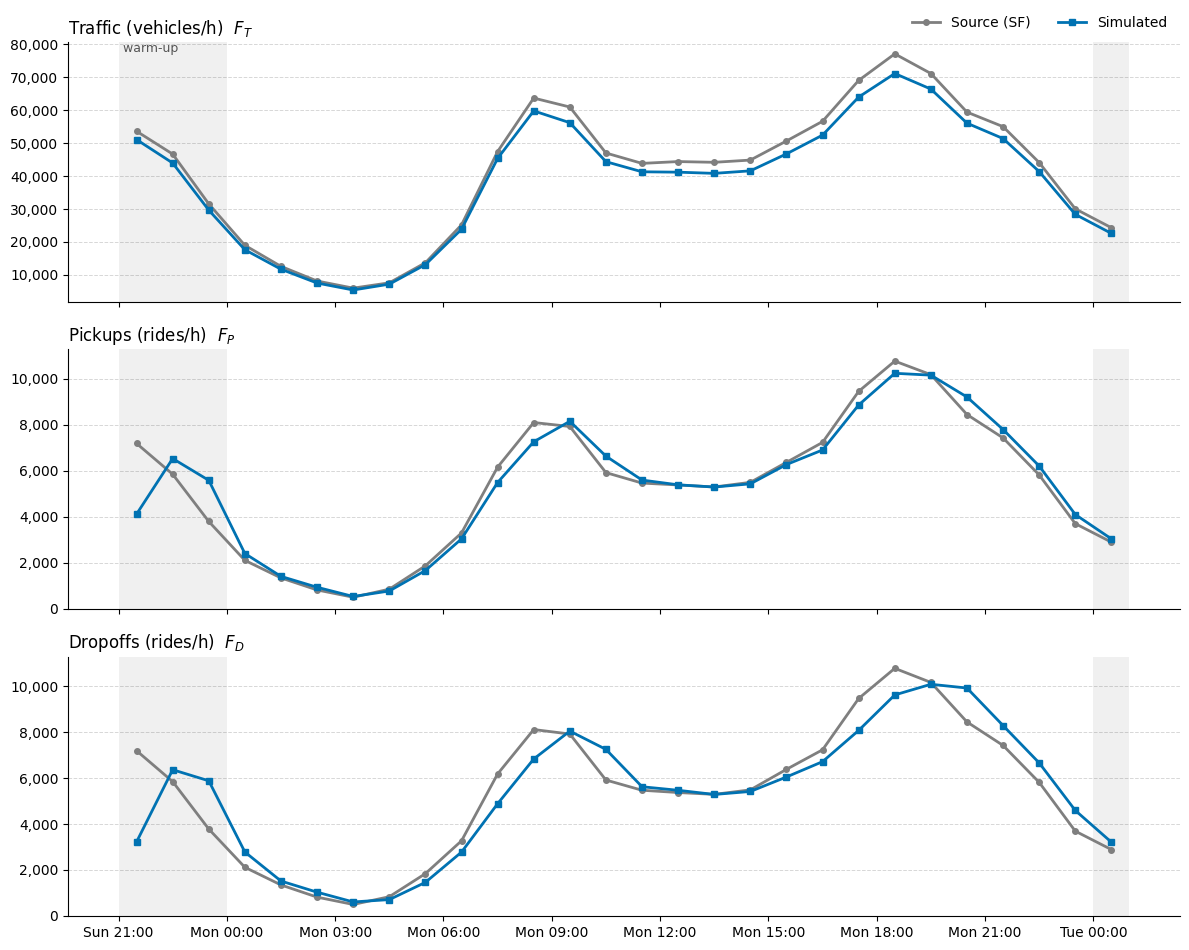

In [8]:
SOURCE_COLOR, SIM_COLOR = "#7F7F7F", "#0072B2"
plot_metrics = METRICS
titles = {"traffic": "Traffic (vehicles/h)", "pickups": "Pickups (rides/h)", "dropoffs": "Dropoffs (rides/h)"}

fig, axes = plt.subplots(len(plot_metrics), 1, figsize=(12, 3.2 * len(plot_metrics)), sharex=True)
axes = np.atleast_1d(axes)
x = hourly["datetime"] + timedelta(minutes=30)
for ax, (metric, (source_col, sim_col, label)) in zip(axes, plot_metrics.items()):
    ax.axvspan(hourly["datetime"].iloc[0], hourly["datetime"].iloc[WARMUP_HOURS[0]], color="#000000", alpha=0.06, lw=0)
    ax.axvspan(hourly["datetime"].iloc[-WARMUP_HOURS[1]], hourly["datetime"].iloc[-1] + timedelta(hours=1), color="#000000", alpha=0.06, lw=0)
    ax.plot(x, hourly[source_col], color=SOURCE_COLOR, lw=2, marker="o", ms=4, label="Source (SF)")
    ax.plot(x, hourly[sim_col], color=SIM_COLOR, lw=2, marker="s", ms=4, label="Simulated")
    ax.set_title(f"{titles[metric]}  {label}", loc="left", fontsize=12)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.7, alpha=0.5)
    ax.set_axisbelow(True)
axes[0].legend(frameon=False, loc="lower right", bbox_to_anchor=(1, 1), ncol=2)
axes[0].text(hourly["datetime"].iloc[0], axes[0].get_ylim()[1], " warm-up", va="top", fontsize=9, color="#555555")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%a %H:%M"))
axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=3))
plt.tight_layout()
plt.savefig(os.path.join(outRoot, "validation_hourly_profiles.png"), dpi=300, bbox_inches="tight")
plt.show()